## ``EDA + Visualization + Pre-Processing - Loan Default``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# Video Games dataset
df_ld = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/LoanDefault/LoanDefault-Dataset.csv', usecols = lambda column: column != 'Unnamed: 0')
df_ld.head(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
# Features type
df_ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
# Features description
df_ld.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


#### ``Visualization``

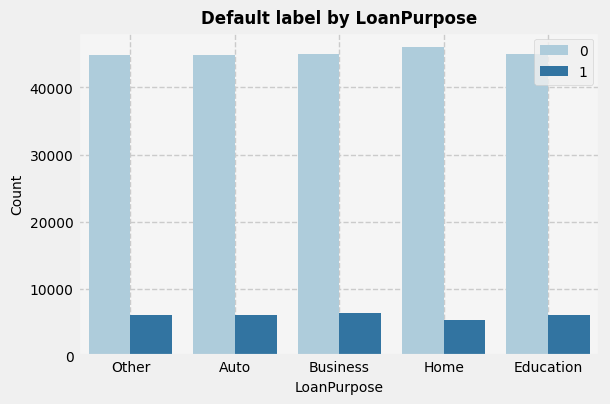

In [5]:
# Visualization - Default label by LoanPurpose
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.countplot(data = df_ld, x = 'LoanPurpose', hue = 'Default', palette = 'Paired')
plt.grid(linestyle = '--')
plt.title('Default label by LoanPurpose', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('LoanPurpose', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

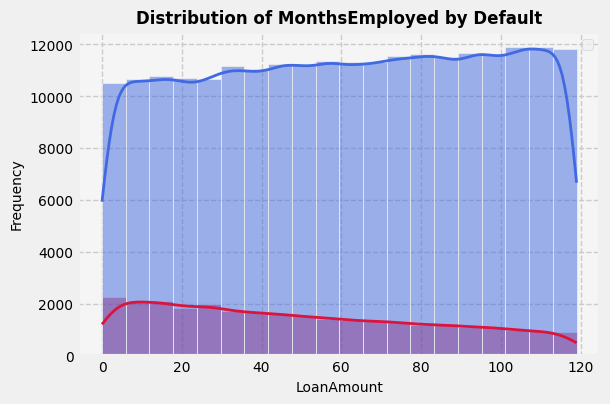

In [6]:
# Visualization - Distribution of MonthsEmployed by Default
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.histplot(df_ld[df_ld['Default'] == 1]['MonthsEmployed'], bins = 20, kde = True, color = 'crimson', line_kws = {'lw': 2})
sns.histplot(df_ld[df_ld['Default'] == 0]['MonthsEmployed'], bins = 20, kde = True, color = 'royalblue', line_kws = {'lw': 2}, alpha = 0.5)
plt.grid(linestyle = '--')
plt.title('Distribution of MonthsEmployed by Default', fontsize = 12, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('LoanAmount', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);


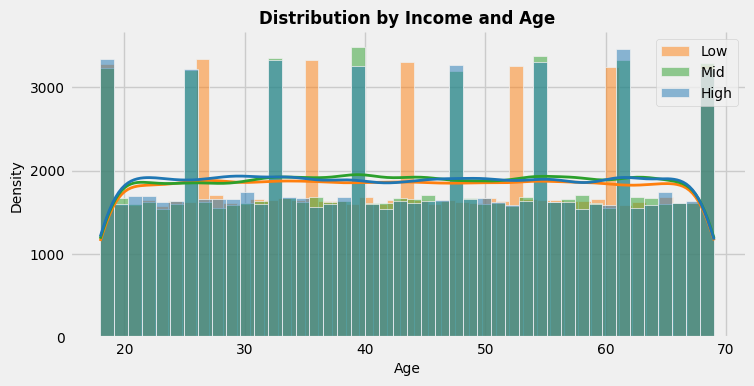

In [7]:
# Visualization - Distribution by Income and Age
df_ld['IncomeGroup'] = pd.qcut(df_ld['Income'], q = 3, labels = ['Low', 'Mid', 'High'])
fig = sns.FacetGrid(df_ld, hue = 'IncomeGroup', height = 4, aspect = 2, palette = ['#ff7f0e', '#2ca02c', '#1f77b4'])
fig.map(sns.histplot, 'Age', kde = True, line_kws = {'lw': 2})
fig.set_axis_labels('Age', 'Density', fontsize = 10) 
plt.title('Distribution by Income and Age', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

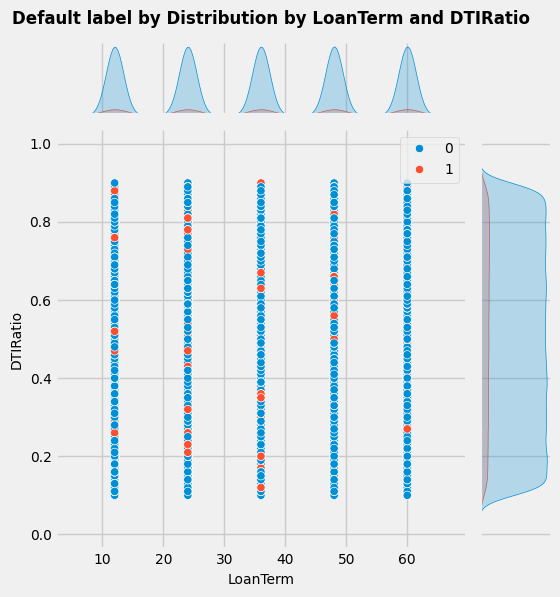

In [8]:
# Visualization - Default label by Distribution by LoanTerm and DTIRatio
fig = sns.jointplot(data = df_ld, x = 'LoanTerm', y = 'DTIRatio', color = 'olive', kind = 'scatter', hue = 'Default')
fig.ax_joint.set_xlabel('LoanTerm', fontsize = 10)
fig.ax_joint.set_ylabel('DTIRatio', fontsize = 10)
fig.ax_joint.tick_params(axis = 'both', labelsize = 10)
plt.suptitle('Default label by Distribution by LoanTerm and DTIRatio', fontsize = 12, fontweight = 'bold', y = 1.02)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

#### ``Data Pre-Processing``

In [9]:
# NA-values
for col in df_ld.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_ld[col].isnull().sum()))

LoanID column missing values: 0
Age column missing values: 0
Income column missing values: 0
LoanAmount column missing values: 0
CreditScore column missing values: 0
MonthsEmployed column missing values: 0
NumCreditLines column missing values: 0
InterestRate column missing values: 0
LoanTerm column missing values: 0
DTIRatio column missing values: 0
Education column missing values: 0
EmploymentType column missing values: 0
MaritalStatus column missing values: 0
HasMortgage column missing values: 0
HasDependents column missing values: 0
LoanPurpose column missing values: 0
HasCoSigner column missing values: 0
Default column missing values: 0
IncomeGroup column missing values: 0


In [10]:
# Feature Selection + Target
X = df_ld.drop(['LoanID', 'IncomeGroup', 'Default'], axis = 1)
Y = df_ld['Default']
print(X.shape)
print(Y.shape)

(255347, 16)
(255347,)


In [11]:
# Categorical features
encoder = LabelEncoder()

categorical_columns = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col].astype(str))
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0


In [12]:
# Numerical features
sc = MinMaxScaler()

numerical_variables = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'NumCreditLines', 'LoanTerm', 'DTIRatio']
for col in numerical_variables:
    X[[col]] = sc.fit_transform(X[[col]])
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,0.745098,0.525885,0.186070,0.400729,0.672269,1.000000,0.575217,0.50,0.4250,0,0,0,1,1,4,1
1,1.000000,0.262461,0.487512,0.287796,0.126050,0.000000,0.122174,1.00,0.7250,2,0,1,0,0,4,1
2,0.549020,0.512656,0.506892,0.275046,0.218487,0.666667,0.833478,0.25,0.2625,2,3,0,1,1,0,0
3,0.274510,0.123801,0.162446,0.806922,0.000000,0.666667,0.220435,0.25,0.1625,1,0,1,0,0,1,0
4,0.823529,0.040274,0.016894,0.606557,0.067227,1.000000,0.196087,0.75,0.7875,0,3,0,0,1,0,0


In [13]:
# User Rating target to categorical
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)
Y = pd.DataFrame(Y, columns = ['Default'])

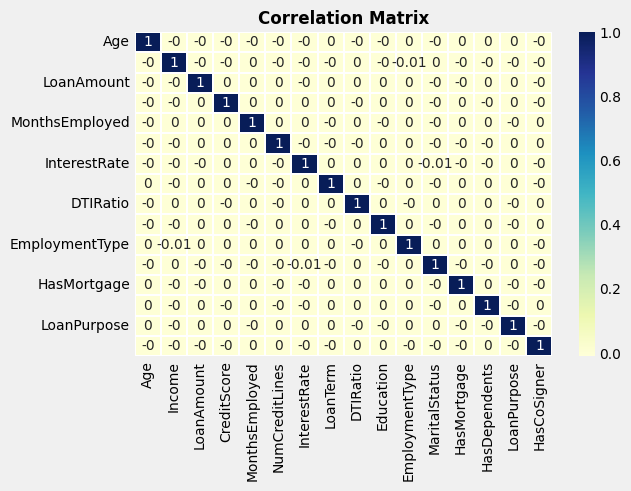

In [14]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [15]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, stratify = Y, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(191510, 16)
(191510, 1)
(63837, 16)
(63837, 1)


In [16]:
# Save to pickle
X_train.to_pickle('../../../data/LoanDefault/X_Train_LoanDefault.pkl')
X_test.to_pickle('../../../data/LoanDefault/X_Test_LoanDefault.pkl')
Y_train.to_pickle('../../../data/LoanDefault/Y_Train_LoanDefault.pkl')
Y_test.to_pickle('../../../data/LoanDefault/Y_Test_LoanDefault.pkl')